# 🧠 Supervised Contrastive Learning (SupCon)

**Part I · CNN Architectures & Visual Representations**

---

## 👤 Instructor

**Ing. Jesús Alan Hernández Galván**

📫 alanhernandezgalvan@icloud.com
🌐 [https://unlikeghost.github.io/](https://unlikeghost.github.io/)

---

## 🗺️ Progreso del curso

1. **CNN: The Feature Extractor** 📍
2. Embedding Architectures & Similarity Learning
3. The SupCon Pipeline (Scalability & Transfer)

---

## 🎯 Objetivo del módulo

Implementar y analizar una **CNN básica**

El enfoque está en entender cómo las capas convolucionales transforman la información visual en representaciones que pueden reutilizarse en tareas posteriores.

# 🧩 Construyendo una CNN básica

In [1]:
import sys

def check_environment():
    if 'google.colab' in sys.modules:
        print("Entorno: Google Colab ☁️")

        from IPython import get_ipython
        ipython = get_ipython()
        if ipython:
            print("Instalando dependencias necesarias...")
            ipython.run_line_magic('pip', 'install --upgrade umap-learn numba')

        return "colab"
    else:
        print("Entorno: Local / Jupyter Notebook")
        return "local"

env = check_environment()

Entorno: Local / Jupyter Notebook


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import os
import logging

os.environ["TORCH_LOGS"] = "-all"
logging.getLogger("torch._inductor").setLevel(logging.ERROR)

In [4]:
if env == 'local':
    import os
    project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.join(project_root, "data")
    models_path = os.path.join(project_root, "models")

else:
    data_path = "./data"
    models_path = "./models"

## Librerias

In [5]:
import umap
import torch
import random
import torchvision

import numpy as np
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from torchsummary import summary
from sklearn.metrics import confusion_matrix

In [6]:
from src.models import LeNet5Classifier as LeNet5
from src.plot_data import show_batch, show_features, plot_latent_space_3d, plot_latent_space_2d

## 🔒 Semilla para reproducibilidad

In [7]:
seed: int = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

## ⚡ Optimización de Aceleración por Hardware (CUDA/cuDNN)

### 🚀 Verificar uso de GPU (si está disponible)

In [8]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
    )
print(f"Status: System ready on {device}")

Status: System ready on cuda


In [9]:
if device == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.allow_tf32 = True

## 🧪 Implementación

### 📦 Carga y preprocesamiento de datos

In [10]:
batch_size: int = 512

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Resize(size=(32, 32)),
     transforms.Normalize(
         mean=(0.485, 0.456, 0.406),
         std=(0.229, 0.224, 0.225)
         ), # ImageNet values
     ]
)

classes: tuple = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

In [11]:
train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

100%|██████████| 170M/170M [03:00<00:00, 947kB/s]  


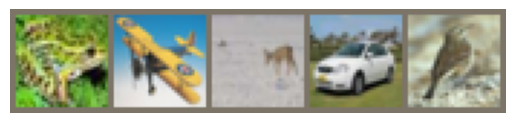

In [12]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images[:5]

show_batch(
    torchvision.utils.make_grid(images),
)

### 🧠 LeNet
![LeNet-5](https://www.philschmid.de/static/blog/getting-started-with-cnn-by-calculating-lenet-layer-manually/lenet-5.svg)

La arquitectura LeNet-5, propuesta por Yann LeCun en 1998, es una de las primeras redes neuronales convolucionales (CNN) y fue diseñada originalmente para el reconocimiento de dígitos escritos a mano (dataset MNIST).


**🎯 Kernel y Stride**

![Stride](https://upload.wikimedia.org/wikipedia/commons/9/92/Convolution_arithmetic_-_Padding_strides_transposed.gif)

El **kernel** (o filtro) es una pequeña matriz que recorre la imagen para detectar patrones locales, como bordes o texturas.
El **stride** define el tamaño del paso con el que este filtro se mueve sobre la imagen: un stride mayor reduce la resolución de salida, mientras que uno menor permite capturar más detalle.

In [13]:
modelo = LeNet5().to(device)
print(modelo)
summary(modelo, input_size=(3, 32, 32))

LeNet5(
  (conv_block): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (mlp): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
              ReLU-2            [-1, 6, 28, 28]               0
         AvgPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
              ReLU-5           [-1, 16, 10, 10]               0
         AvgPool2d-6        

### ⚙️ Proceso de entrenamiento

#### 📉 Optimización (Loss & Optimizer)

![Gradient Descent](https://miro.medium.com/v2/resize:fit:1200/1*STiRp7PW5yIrvYZupZA6nw.gif)

Durante el entrenamiento, el modelo ajusta sus parámetros para minimizar el error.
La **función de pérdida** mide qué tan lejos están las predicciones de los valores reales, mientras que el **optimizador** guía la actualización de los pesos siguiendo la dirección que reduce ese error.

Este proceso, conocido como *gradient descent*, consiste en dar pequeños pasos hacia el mínimo de la función de pérdida en cada iteración.

#### 🚀 Entrenamiento del modelo


In [14]:
num_epochs: int = 50
model = LeNet5().to(device)
model = torch.compile(model)

criterion = nn.CrossEntropyLoss() # función de perdida
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Optimizador

In [15]:
train_loss = []
train_acc = []

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")

Epoch [1/50] - Loss: 1.8847 - Acc: 0.3222
Epoch [2/50] - Loss: 1.5468 - Acc: 0.4451
Epoch [3/50] - Loss: 1.4459 - Acc: 0.4849
Epoch [4/50] - Loss: 1.3743 - Acc: 0.5092
Epoch [5/50] - Loss: 1.3251 - Acc: 0.5282
Epoch [6/50] - Loss: 1.2854 - Acc: 0.5420
Epoch [7/50] - Loss: 1.2446 - Acc: 0.5574
Epoch [8/50] - Loss: 1.2128 - Acc: 0.5692
Epoch [9/50] - Loss: 1.1840 - Acc: 0.5821
Epoch [10/50] - Loss: 1.1527 - Acc: 0.5920
Epoch [11/50] - Loss: 1.1255 - Acc: 0.6029
Epoch [12/50] - Loss: 1.0971 - Acc: 0.6121
Epoch [13/50] - Loss: 1.0824 - Acc: 0.6176
Epoch [14/50] - Loss: 1.0568 - Acc: 0.6259
Epoch [15/50] - Loss: 1.0339 - Acc: 0.6342
Epoch [16/50] - Loss: 1.0114 - Acc: 0.6424
Epoch [17/50] - Loss: 0.9923 - Acc: 0.6491
Epoch [18/50] - Loss: 0.9734 - Acc: 0.6564
Epoch [19/50] - Loss: 0.9527 - Acc: 0.6632
Epoch [20/50] - Loss: 0.9364 - Acc: 0.6704
Epoch [21/50] - Loss: 0.9242 - Acc: 0.6732
Epoch [22/50] - Loss: 0.9039 - Acc: 0.6799
Epoch [23/50] - Loss: 0.8875 - Acc: 0.6873
Epoch [24/50] - Loss

In [27]:
torch.save(
    model.state_dict(),
    os.path.join(models_path, "lenet5_cifar10.pth")
)

### 📊 Métricas de entrenamiento y validación

#### 📊 Entrenamiento

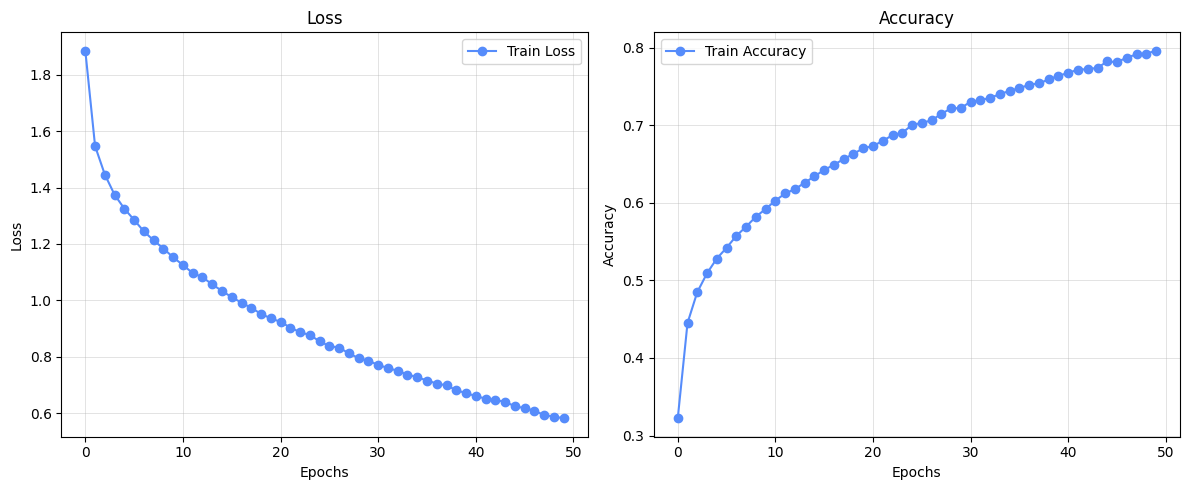

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(train_loss, label='Train Loss', marker='o')
axs[0].set_title('Train Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(train_acc, label='Train Accuracy', marker='o')
axs[1].set_title('Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 📊 Validación

In [17]:
model.eval() # Nos aseguramos de que esté en modo evaluación

all_preds = []
all_labels = []

# 1. Pasamos TODAS las imágenes de test por el modelo sin calcular gradientes
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)

        # torch.max nos devuelve el valor máximo y su ÍNDICE (la clase predicha)
        _, predicted = torch.max(outputs, 1)

        # Guardamos las predicciones y las etiquetas reales en la CPU
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

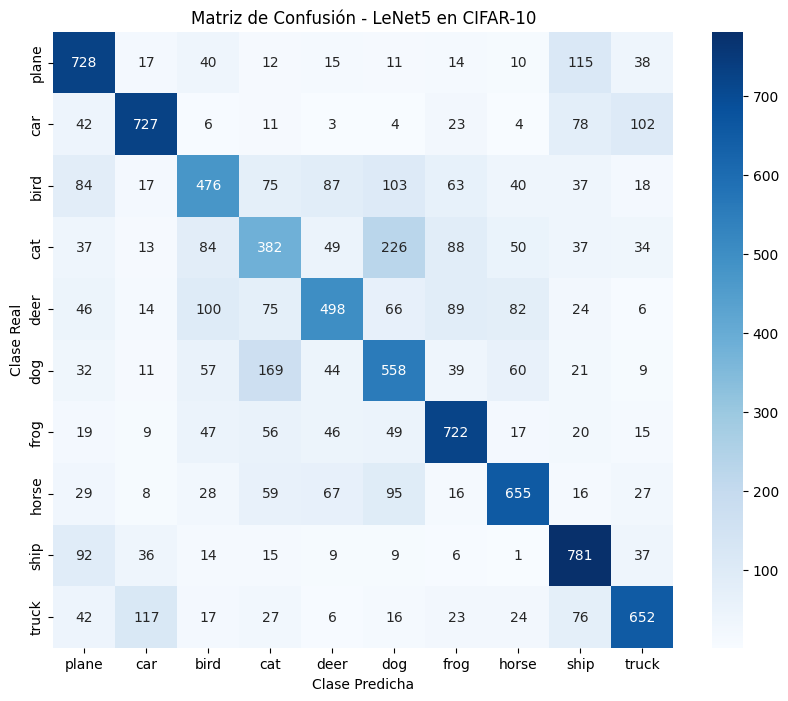

In [18]:
# 2. Creamos la matriz numérica con sklearn
cm = confusion_matrix(all_labels, all_preds)

# 3. Dibujamos la matriz
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión - LeNet5 en CIFAR-10')
plt.show()

### 🔍 Visualización de features

#### 🧩 Feature Maps

In [19]:
model.eval()

images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

images_batch = images_batch[:5, :, :, :]

with torch.no_grad():
    # Extraer features de la PRIMERA capa (índice 0 es Conv1, índice 1 es ReLU)
    # Pasamos solo por las primeras 2 capas del bloque
    features_conv1 = model.conv_block[:2](images_batch)

    # Extraer features de la SEGUNDA capa (índice 3 es Conv2, índice 4 es ReLU)
    # Pasamos por las primeras 5 capas del bloque
    features_conv2 = model.conv_block[:5](images_batch)


images_np = images_batch.cpu().numpy()
feat1_np = features_conv1.cpu().numpy() # Forma: (32, 6, 28, 28)
feat2_np = features_conv2.cpu().numpy() # Forma: (32, 16, 10, 10)

feat1_np.shape, feat2_np.shape

((5, 6, 28, 28), (5, 16, 10, 10))

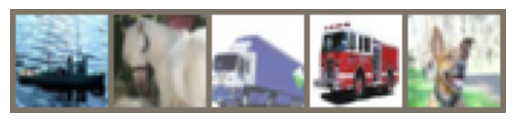

Canal 0


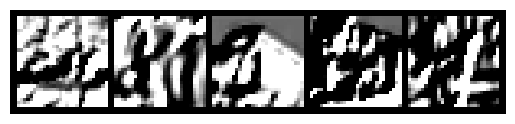

Canal 1


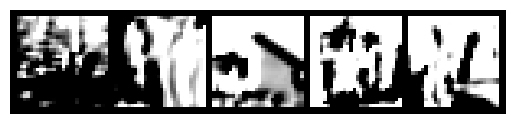

Canal 2


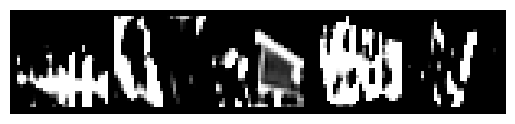

Canal 3


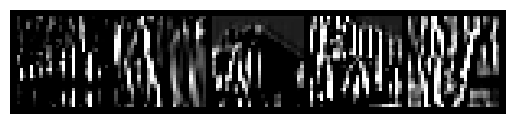

Canal 4


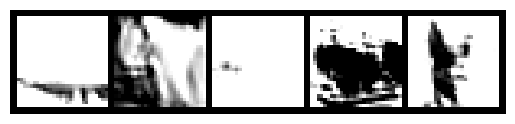

Canal 5


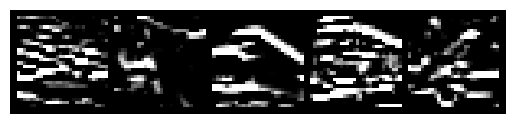

Canal 0


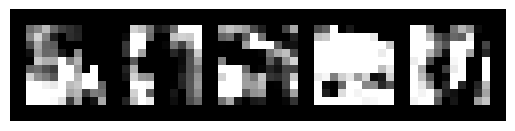

Canal 1


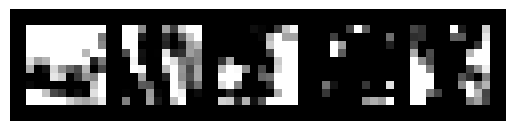

Canal 2


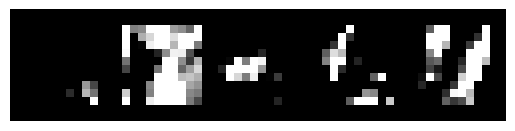

Canal 3


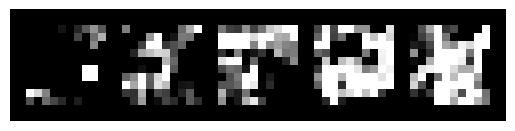

Canal 4


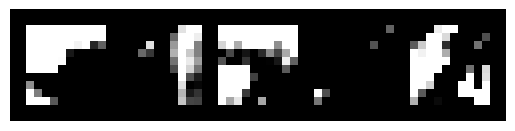

Canal 5


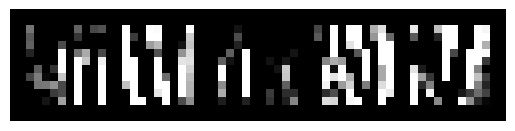

Canal 6


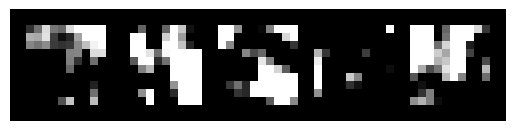

Canal 7


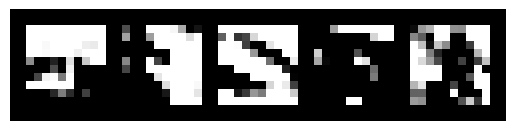

Canal 8


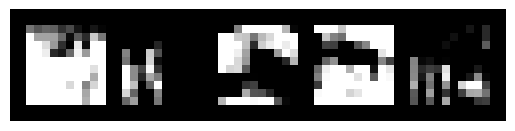

Canal 9


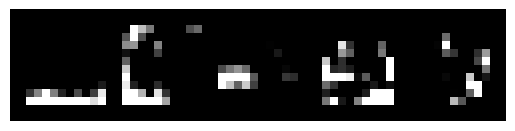

Canal 10


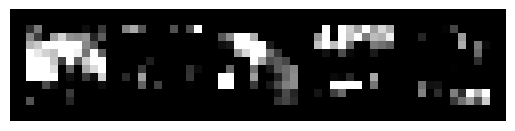

Canal 11


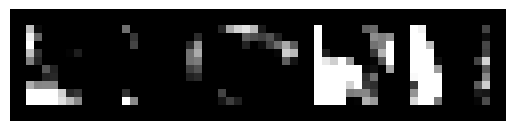

Canal 12


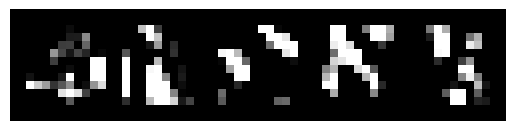

Canal 13


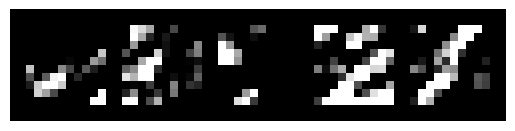

Canal 14


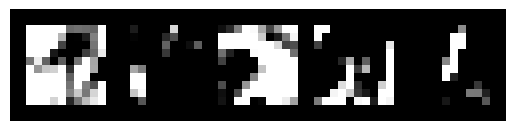

Canal 15


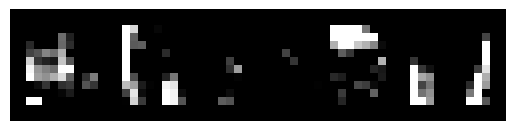

In [21]:
show_batch(
    torchvision.utils.make_grid(images_batch.to('cpu')),
)

for i in range(0, 6):
  print(f"Canal {i}")
  show_features(features_conv1, filter_index=i)

for i in range(0, 16):
  print(f"Canal {i}")
  show_features(features_conv2, filter_index=i)

#### 🧩 Proyección del espacio latente

El **espacio latente** es la representación interna que el modelo construye a partir de los datos de entrada.
En lugar de trabajar directamente con píxeles, la red transforma la información en un conjunto de características más compactas y significativas.

![Latent Space CNN](https://media.springernature.com/lw685/springer-static/image/chp%3A10.1007%2F978-981-16-3357-7_8/MediaObjects/512874_1_En_8_Fig1_HTML.png)

En modelos como **LeNet**, esta representación se obtiene después del *flatten* y las capas totalmente conectadas.

![Latent Visualization](https://www.baeldung.com/wp-content/uploads/sites/4/2022/03/1_latent-1024x307.png)

En este espacio, cada imagen es un punto.
Imágenes similares tienden a estar cerca, mientras que diferentes se separan.

El **espacio latente** no solo sirve para clasificar.
Una vez que el modelo transforma la imagen en esta representación, puede reutilizarse para distintos objetivos como **clasificación**, **regresión** o incluso **reconstrucción**.

Es decir, el modelo primero aprende una buena representación… y luego esa representación se adapta a la tarea que necesites.

In [22]:
model.eval()

all_features = []
all_labels = []

model.eval()

# 1. Extraemos representaciones latentes (antes de la capa final)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # CNN
        x = model.conv_block(images)
        x = x.view(x.size(0), -1)

        # Pasamos por el MLP SIN la última capa (clasificación)
        x = model.mlp[:-1](x)

        # Guardamos
        all_features.append(x.cpu().numpy())
        all_labels.append(labels.numpy())

# Concatenamos todo en un solo array gigante
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_features.shape, all_labels.shape

((10000, 84), (10000,))

##### 🧩 3D

In [23]:
umap_embeddings = umap.UMAP(n_components=3).fit_transform(all_features)
umap_embeddings.shape

(10000, 3)

In [24]:
plot_latent_space_3d(
    umap_embeddings,
    all_labels,
    classes
)

##### 🧩 2D

In [25]:
umap_embeddings_2d = umap.UMAP(n_components=2).fit_transform(all_features)
umap_embeddings_2d.shape

(10000, 2)

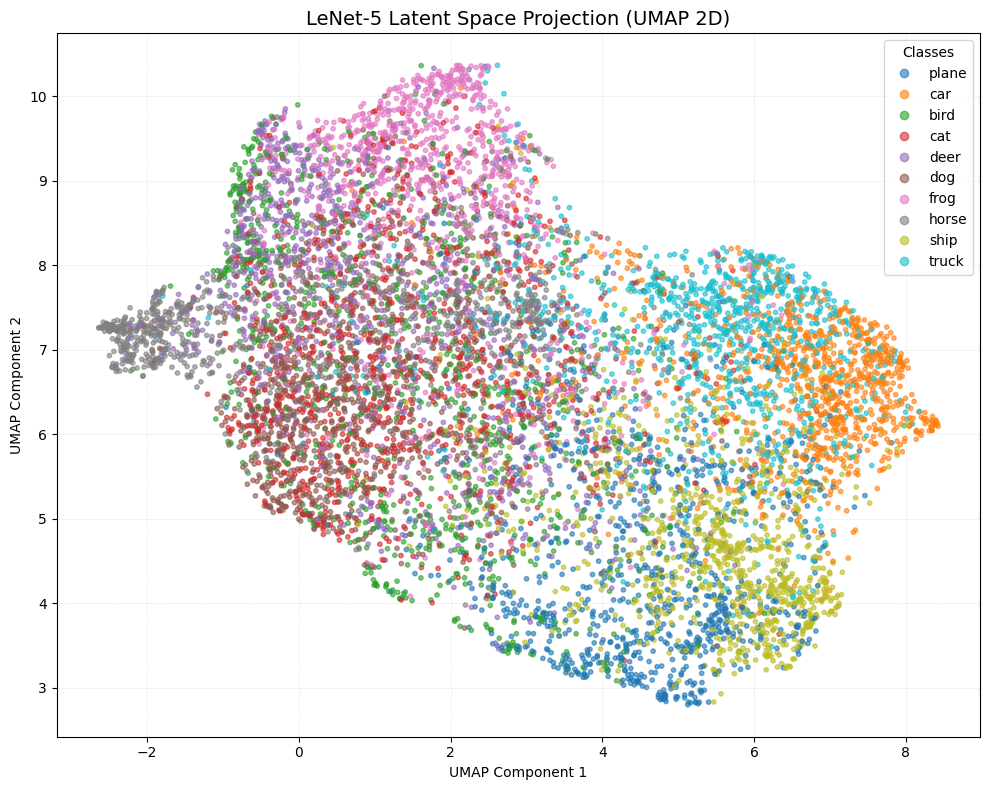

In [26]:
plot_latent_space_2d(
    umap_embeddings_2d,
    all_labels,
    classes
)